Import libraries to project

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

Import data set

In [16]:
plcData = Table.read("Planet_Lightcurve.fits",format = "fits")
print(plcData)

    time [days]             flux       
-------------------- ------------------
                -0.3 0.9718556446853187
 -0.2993993993993994  0.974430548606305
 -0.2987987987987988 0.9696244442016453
 -0.2981981981981982 0.9672472927361904
 -0.2975975975975976 0.9739989623419928
  -0.296996996996997 0.9689265223770298
-0.29639639639639637 0.9678268042192515
 -0.2957957957957958 0.9676453996308826
-0.29519519519519516 0.9703558446606856
 -0.2945945945945946 0.9738800653806102
                 ...                ...
  0.2945945945945945 0.9914653112446374
 0.29519519519519516 0.9978371225844164
  0.2957957957957958  1.000796759382211
  0.2963963963963964 0.9968976911446861
 0.29699699699699694 1.0017105738372651
  0.2975975975975976 1.0025198411286196
  0.2981981981981982 0.9930781407930032
 0.29879879879879884 0.9969834224859118
 0.29939939939939936 0.9998456765152839
                 0.3 0.9997001308741668
Length = 1000 rows


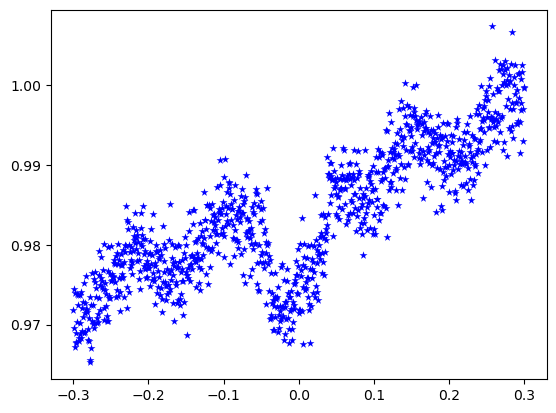

In [17]:
plt.scatter(plcData["time [days]"],plcData["flux"],c='b',marker='*',linewidth=0.0025)

Begining Part 5

In [18]:
time = np.asarray(plcData["time [days]"]) #days
flux = np.asarray(plcData["flux"]) #units?
print(f"the mean of the flux is: {np.mean(flux)}")
print(f"the std of the flux is: {np.std(flux)}")

the mean of the flux is: 0.9837119711489781
the std of the flux is: 0.008588310477699354


In [19]:
print(time[991])
#print("Old flux =",flux[991])
fluxOutlire = flux[991]+(flux[991] * 0.1)
#print("New flux:",fluxOutlire)

0.29519519519519516


In [20]:
fluxArrayOne = flux[0:991]
fluxTest = fluxArrayOne[990]
#print(fluxArrayOne)
fluxArrayTwo = flux[992:1000]
#print(fluxArrayTwo)

In [21]:
fluxArrayOne = np.append(fluxArrayOne, fluxOutlire)
#print(fluxArrayOne)

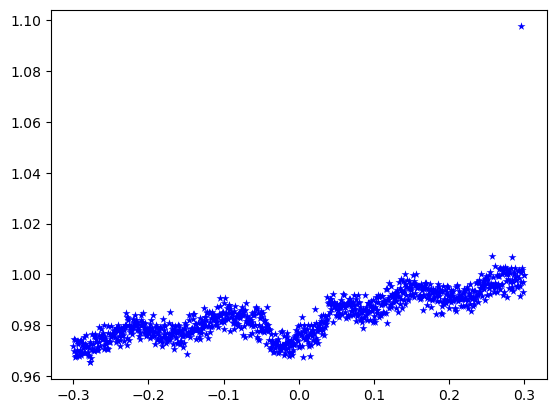

In [22]:
fluxArrayNew = np.append(fluxArrayOne, fluxArrayTwo)
plt.scatter(plcData["time [days]"],fluxArrayNew,c='b',marker='*',linewidth=0.0025)
#plt.vlines(-0.055,0.95,1, colors = "orange")
#plt.vlines(0.055,0.95,1, colors = "orange")
#print(fluxArrayNew[991])
#print(len(fluxArrayNew))

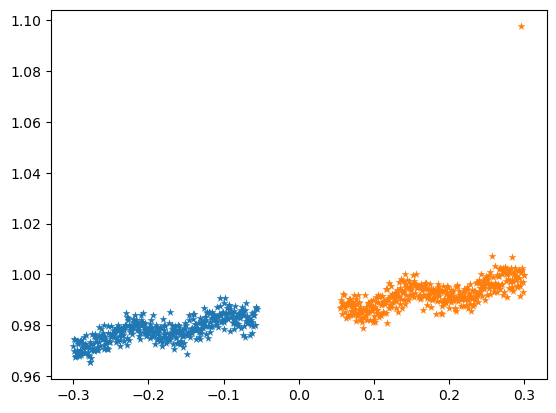

In [23]:
"""
#print(time)
for i in range(len(time)):
    index = time[i]
   # print(index)
    if index == 0.055555555555555525:
        print("i =",i)
print (fluxArrayNew[407])
print (fluxArrayNew[592])
print(time[407])
"""
plt.scatter(time[0:407],fluxArrayNew[0:407], linewidth=0.0025, marker = "*")
plt.scatter(time[592:],fluxArrayNew[592:],linewidth=0.0025, marker = "*")

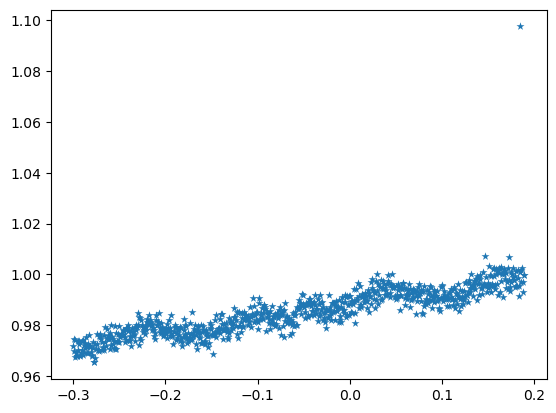

In [24]:
fluxRTOne = fluxArrayNew[0:407]
fluxRTTwo = fluxArrayNew[592:]
fluxRTROOne = flux[0:407]
fluxRTROTwo = flux[592:]
fluxRTRO = np.append(fluxRTROOne,fluxRTROTwo)
fluxRT = np.append(fluxRTOne,fluxRTTwo)
timeNew = time[0:len(fluxRT)]
plt.scatter(timeNew,fluxRT, linewidth=0.0025, marker = "*")

(0.96, 1.1)

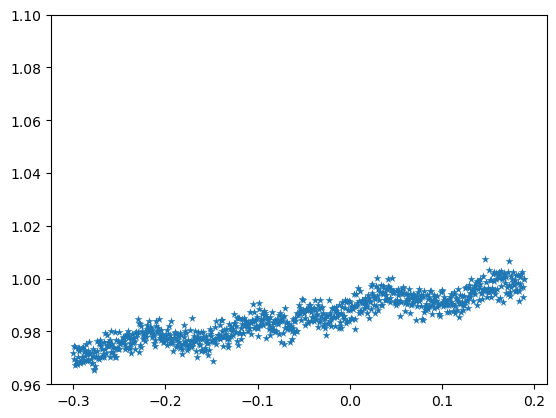

In [25]:
plt.scatter(timeNew, fluxRTRO, linewidth=0.0025, marker = "*")
plt.ylim(0.96, 1.10)

In [26]:
distanceFromMean = fluxOutlire - np.mean(fluxRT)
#print(distanceFromMean)
sigmaDistance = distanceFromMean / np.std(fluxRT)
print(f"The N-sigma is {sigmaDistance}")

The N-sigma is 11.984856442278257


In [27]:
from scipy.special import erf
def eventProbability(x, mu = 0.0, std = 0.0):
    z = np.fabs((x-mu)/std)
    def zfunc(z):
        return 0.5 * (1.0 + erf(z/2**0.5))
    return 1.0 - (zfunc(z) - zfunc(-1*z))
def criterion(prior_measurments,outlire):
    mean = np.mean(fluxRTRO)
    std = np.std(fluxRTRO)
    outlire_probability = eventProbability(fluxOutlire, mean,std)
    N = len(prior_measurments)+1
    if (N*outlire_probability<0.5):
        if(outlire_probability < 1./float(2*N)):
            return True
    return False                                                         

In [28]:
test = criterion(fluxRTRO,fluxOutlire)
result = "accept"
if test == True:
    result = "reject"
    testString = "true"
print(f"The Chavenet Criterion is {testString}, so we can {result} the outlire")

The Chavenet Criterion is true, so we can reject the outlire
